In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
data = {
    'Weather': ['Sunny', 'Sunny', 'Rainy', 'Rainy',
                'Sunny', 'Rainy', 'Sunny', 'Rainy',
                'Sunny', 'Rainy', 'Sunny', 'Rainy'],

    'Activity': ['Go out', 'Go out', 'Stay in', 'Stay in',
                 'Go out', 'Stay in', 'Go out', 'Stay in',
                 'Go out', 'Stay in', 'Go out', 'Stay in']
}

data = pd.DataFrame(data)

print(data)

   Weather Activity
0    Sunny   Go out
1    Sunny   Go out
2    Rainy  Stay in
3    Rainy  Stay in
4    Sunny   Go out
5    Rainy  Stay in
6    Sunny   Go out
7    Rainy  Stay in
8    Sunny   Go out
9    Rainy  Stay in
10   Sunny   Go out
11   Rainy  Stay in


In [3]:
print(data.isnull().sum())

Weather     0
Activity    0
dtype: int64


In [4]:
data['Weather'] = data['Weather'].map({
    'Sunny': 1,
    'Rainy': 0
})

data['Activity'] = data['Activity'].map({
    'Go out': 1,
    'Stay in': 0
})

print(data)

    Weather  Activity
0         1         1
1         1         1
2         0         0
3         0         0
4         1         1
5         0         0
6         1         1
7         0         0
8         1         1
9         0         0
10        1         1
11        0         0


In [5]:
X = data[['Weather']]
y = data['Activity']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(9, 1)
(9,)
(3, 1)
(3,)


In [7]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [8]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0]


In [9]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Confusion Matrix:
[[3]]
Accuracy Score: 1.0
Accuracy in Percentage: 100 %


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


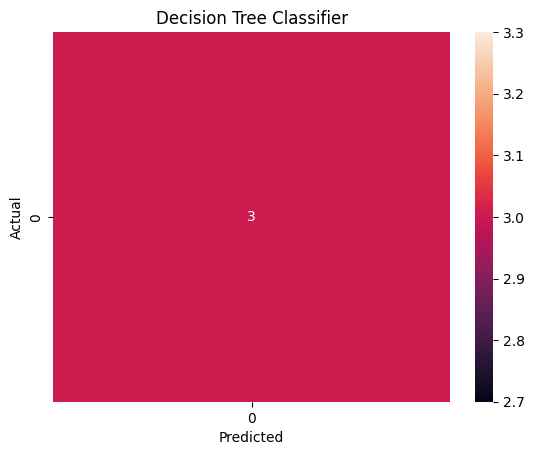

In [10]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)
plt.title("Decision Tree Classifier")
plt.show()

In [11]:
print("Sunny:",
      "Go out" if model.predict(pd.DataFrame([[1]], columns=["Weather"]))[0] == 1 else "Stay in")

print("Rainy:",
      "Go out" if model.predict(pd.DataFrame([[0]], columns=["Weather"]))[0] == 1 else "Stay in")

Sunny: Go out
Rainy: Stay in
